In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [83]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Leaf_Classification_System/train.csv")   # update path if needed

print("Shape:", df.shape)
df.head()

Shape: (990, 194)


,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,1,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,2,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,3,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,5,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,6,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


In [102]:
print("Number of classes:", df['species'].nunique())
print("Number of features:", df.shape[1] - 2)

Number of classes: 99
Number of features: 192


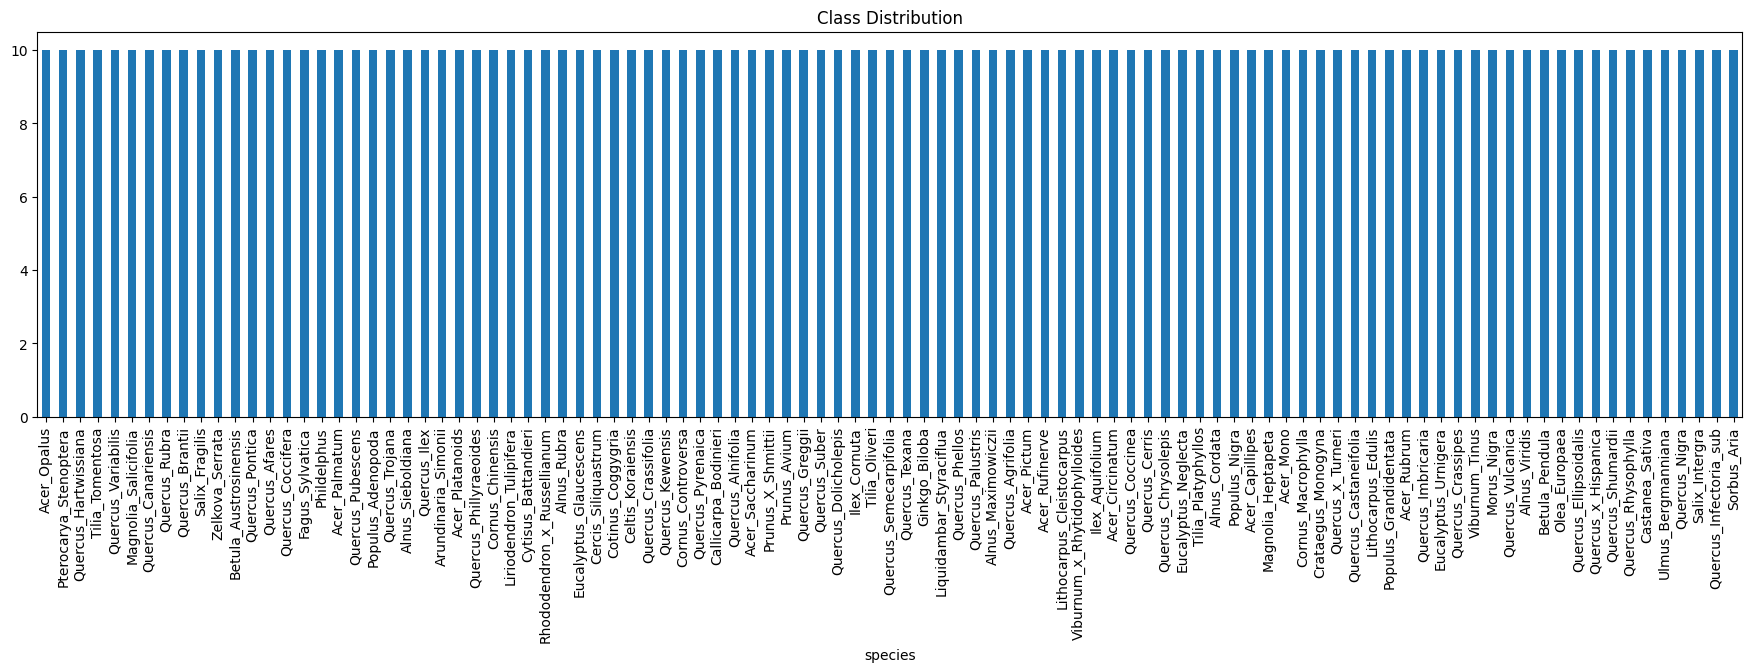

In [104]:
plt.figure(figsize=(22,5))
df['species'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.show()

In [105]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(['id', 'species'], axis=1)
y = df['species']

le = LabelEncoder()
y = le.fit_transform(y)

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [107]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=25, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [108]:
y_pred = model.predict(X_val)

In [109]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_val, y_pred)
print("Final Accuracy:", acc)

Final Accuracy: 0.9797979797979798


In [110]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       1.00    

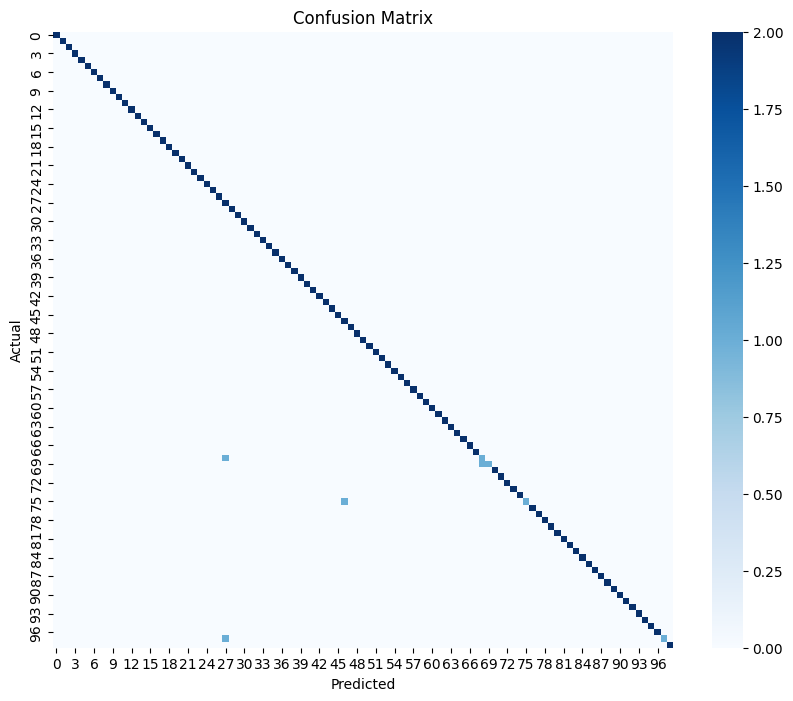

In [111]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

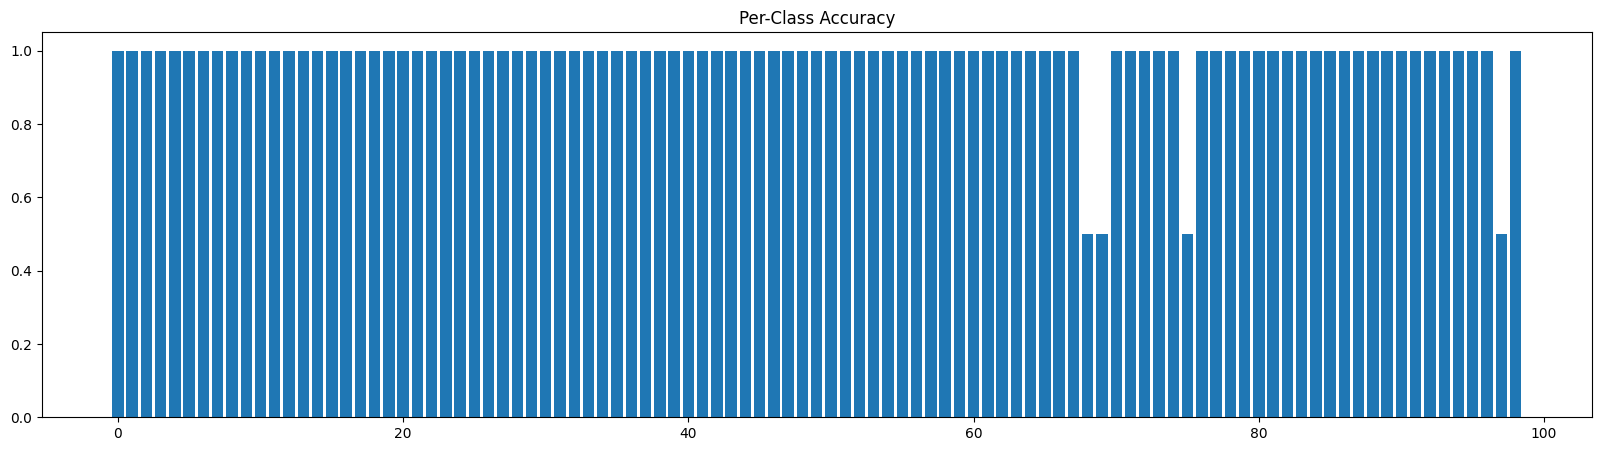

In [112]:
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(20,5))
plt.bar(range(len(class_acc)), class_acc)

plt.title("Per-Class Accuracy")
plt.show()

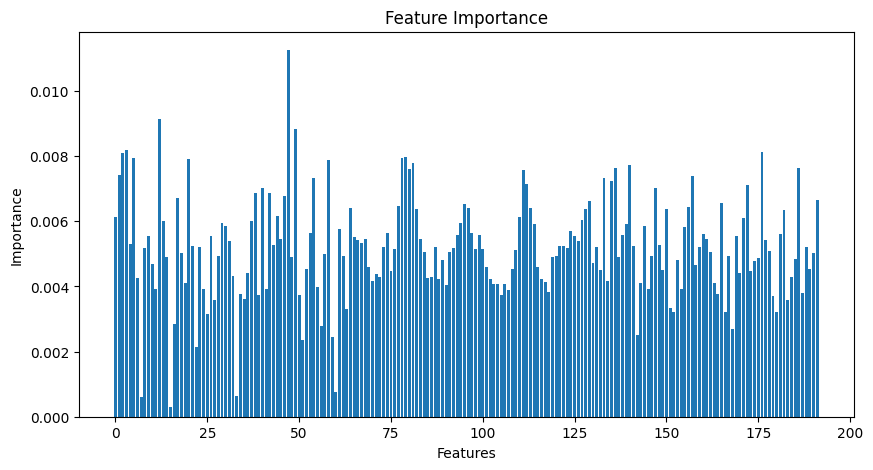

In [113]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

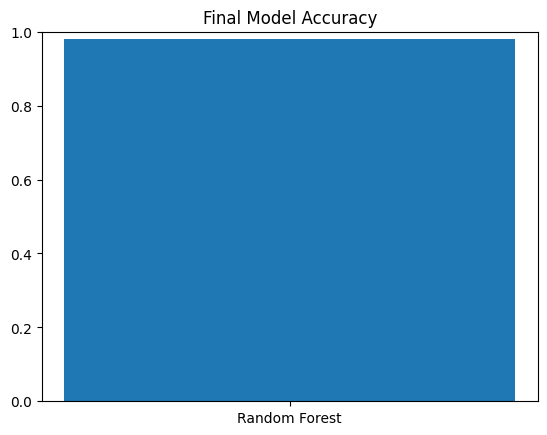

In [114]:
plt.bar(['Random Forest'], [acc])
plt.ylim(0,1)

plt.title("Final Model Accuracy")
plt.show()

In [115]:
sample = X_val[0].reshape(1, -1)

pred = model.predict(sample)

print("Predicted Class:", le.inverse_transform(pred)[0])

Predicted Class: Acer_Mono
